<a href="https://colab.research.google.com/github/dbansal02/SciML_ME697_Project/blob/main/PIFT_Examples_5_1_to_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics-Informed Information Field Theory (PIFT) Examples in JAX

This notebook implements selected numerical examples from Alberts and Bilionis, *Physics-informed information field theory for modeling physical systems with uncertainty quantification*.

The notebook focuses on two parts:

1. **Example 5.1:** a one-dimensional steady-state heat equation used to study how the inverse-temperature parameter \(\beta\) controls the concentration of the physics-informed field distribution.
2. **Example 5.3:** nonlinear inverse problems in which the physical parameters $D$ and $\kappa$, and in one case the source term $(f(x))$, are inferred from noisy field observations.

All computationally intensive sampling routines are written in JAX and are intended to run efficiently on GPU hardware such as an NVIDIA A100.


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)
D = 0.25
phi_left = 1.0
phi_right = 0.1
K = 20
x_plot = jnp.linspace(0.0, 1.0, 400)
def q_source(x):
    return jnp.exp(-x)


## Boundary-enforcing Fourier parameterization
For the heat equation, the field is represented as:

$$\hat{\phi}(x;\theta) = (1-x)\phi(0) + x\phi(1) + (1-x)x \psi(x;\theta)$$

where $\psi(x;\theta)$ is a truncated Fourier series. The factor $(1-x)x$ vanishes at both boundaries, so the prescribed boundary conditions are satisfied exactly for every coefficient vector $\theta$.

In [2]:
def psi(x, theta):
    """
    Truncated Fourier series:
        psi(x) = a0 + sum_{j=1}^K [a_j cos(2 pi j x) + b_j sin(2 pi j x)]
    theta has length 1 + 2K:
        theta = [a0, a1, ..., aK, b1, ..., bK]
    """
    a0 = theta[0]
    a_cos = theta[1:K+1]
    b_sin = theta[K+1:2*K+1]
    j = jnp.arange(1, K + 1)
    x = jnp.atleast_1d(x)
    cos_terms = jnp.cos(2.0 * jnp.pi * j[None, :] * x[:, None])
    sin_terms = jnp.sin(2.0 * jnp.pi * j[None, :] * x[:, None])
    val = (
        a0
        + jnp.sum(a_cos[None, :] * cos_terms, axis=1)
        + jnp.sum(b_sin[None, :] * sin_terms, axis=1)
    )
    return val
def phi_hat(x, theta):
    """
    Boundary-condition-satisfying field parameterization.
    """
    x = jnp.atleast_1d(x)
    base = (1.0 - x) * phi_left + x * phi_right
    return base + (1.0 - x) * x * psi(x, theta)


## Boundary-condition sanity check
The first check verifies that the parameterization satisfies:

$$\hat{\phi}(0;\theta)=1, \qquad \hat{\phi}(1;\theta)=0.1$$

for arbitrary Fourier coefficients. This confirms that the boundary constraints are built into the representation rather than enforced by a penalty term.

In [3]:
key = jax.random.PRNGKey(0)
theta_test = jax.random.normal(key, shape=(1 + 2*K,))
print("theta length:", theta_test.shape[0])
print("phi(0) =", float(phi_hat(jnp.array([0.0]), theta_test)[0]))
print("phi(1) =", float(phi_hat(jnp.array([1.0]), theta_test)[0]))


theta length: 41
phi(0) = 1.0
phi(1) = 0.1


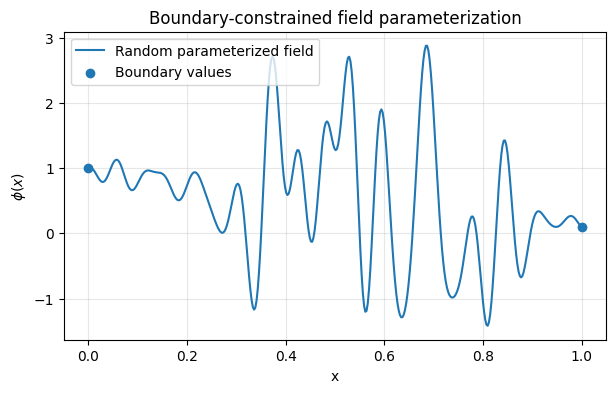

In [4]:
phi_test = phi_hat(x_plot, theta_test)
plt.figure(figsize=(7, 4))
plt.plot(x_plot, phi_test, label="Random parameterized field")
plt.scatter([0.0, 1.0], [phi_left, phi_right], zorder=3, label="Boundary values")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Boundary-constrained field parameterization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Physics-informed energy functional
The steady-state heat equation is encoded through the Dirichlet energy:

$$U[\phi] = \int_0^1 \left[ \frac{1}{2}D\left(\frac{d\phi}{dx}\right)^2 - \phi(x)q(x) \right]dx$$

The minimizer of this functional satisfies the corresponding Euler-Lagrange equation. In the finite-dimensional implementation, $\phi$ is replaced by $\hat{\phi}(x;\theta)$, derivatives are computed with JAX automatic differentiation, and the integral is approximated on a fixed grid.

In [5]:
def dphi_dx(x, theta):
    """
    Computes d(phi)/dx using JAX automatic differentiation.
    """
    def phi_single(x_scalar):
        return phi_hat(jnp.array([x_scalar]), theta)[0]
    return jax.vmap(jax.grad(phi_single))(x)


In [6]:
def energy_U(theta):
    x = x_plot
    phi_vals = phi_hat(x, theta)
    dphi_vals = dphi_dx(x, theta)
    integrand = 0.5 * D * dphi_vals**2 - phi_vals * q_source(x)
    dx = x[1] - x[0]
    return jnp.sum(integrand) * dx


In [7]:
U_val = energy_U(theta_test)
print("Energy U(theta_test) =", float(U_val))


Energy U(theta_test) = 502.05534696338475


## Deterministic energy minimization

Before sampling from the PIFT prior, the energy implementation is checked deterministically. If the energy and boundary-constrained parameterization are correct, minimizing \(U(\theta)\) should recover the reference solution of the boundary-value problem.

The optimization uses L-BFGS-B with exact JAX gradients. This provides a stable deterministic verification step before running stochastic Langevin sampling.


In [8]:
from scipy.optimize import minimize
import numpy as np
energy_grad = jax.jit(jax.grad(energy_U))
energy_val = jax.jit(energy_U)
def lbfgs_optimize(theta_init):
    """
    Minimize the energy using L-BFGS-B (scipy) with JAX-computed gradients.
    The energy is quadratic in theta (linear PDE), so this converges quickly.
    """
    loss_history = []
    def loss_and_grad(theta_np):
        theta_jax = jnp.array(theta_np)
        val = float(energy_val(theta_jax))
        grad = np.array(energy_grad(theta_jax), dtype=np.float64)
        loss_history.append(val)
        return val, grad
    result = minimize(
        loss_and_grad,
        np.array(theta_init, dtype=np.float64),
        method="L-BFGS-B",
        jac=True,
        options={"maxiter": 5000, "ftol": 1e-15, "gtol": 1e-10},
    )
    return jnp.array(result.x), jnp.array(loss_history), result


In [9]:
key = jax.random.PRNGKey(42)
theta0 = 0.01 * jax.random.normal(key, shape=(1 + 2*K,))
theta_opt, loss_hist, opt_result = lbfgs_optimize(theta0)
print("Initial energy :", float(energy_val(theta0)))
print("Final energy   :", float(energy_val(theta_opt)))
print("Converged      :", opt_result.success)
print("Message        :", opt_result.message)
print("Iterations     :", opt_result.nit)


Initial energy : -0.24801327824473338
Final energy   : -0.35910456102537824
Converged      : True
Message        : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Iterations     : 258


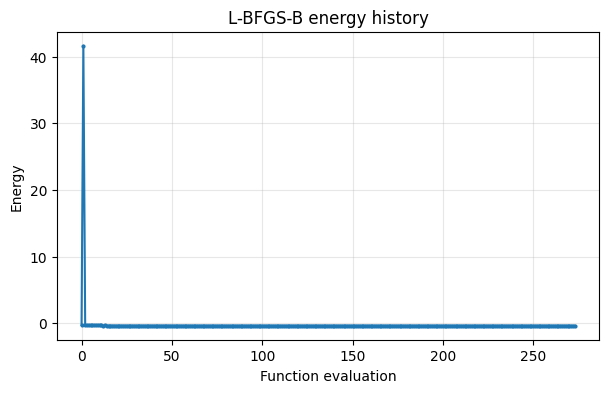

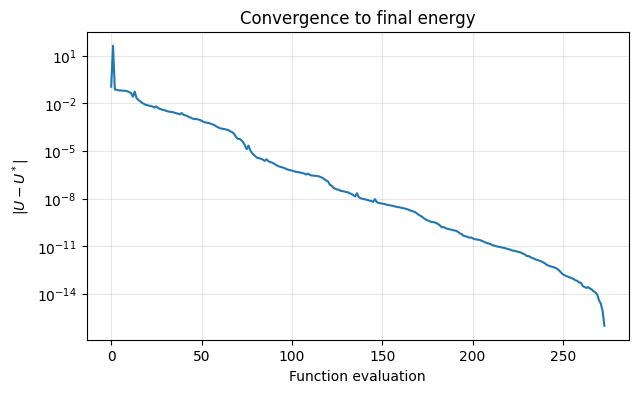

In [10]:
plt.figure(figsize=(7,4))
plt.plot(loss_hist, marker='o', ms=2)
plt.xlabel("Function evaluation")
plt.ylabel("Energy")
plt.title("L-BFGS-B energy history")
plt.grid(True, alpha=0.3)
plt.show()
plt.figure(figsize=(7,4))
plt.semilogy(np.abs(loss_hist - loss_hist[-1]) + 1e-16)
plt.xlabel("Function evaluation")
plt.ylabel(r"$|U - U^*|$")
plt.title("Convergence to final energy")
plt.grid(True, alpha=0.3)
plt.show()


## Analytical reference solution
For Example 5.1, the governing equation is:

$$D\frac{d^2\phi}{dx^2} + e^{-x}=0$$

Integrating twice gives:

$$\phi(x) = -\frac{e^{-x}}{D} + C_1x + C_2$$

where the constants are determined by $\phi(0)=1$ and $\phi(1)=0.1$:

$$C_2 = 1 + \frac{1}{D}, \qquad C_1 = 0.1 - 1 - \frac{1}{D} + \frac{e^{-1}}{D}$$

This closed-form solution is used only as a reference for verification and plotting.

In [11]:
def phi_exact(x):
    C2 = 1.0 + 1.0 / D
    C1 = 0.1 - C2 + jnp.exp(-1.0) / D
    return -(1.0 / D) * jnp.exp(-x) + C1 * x + C2


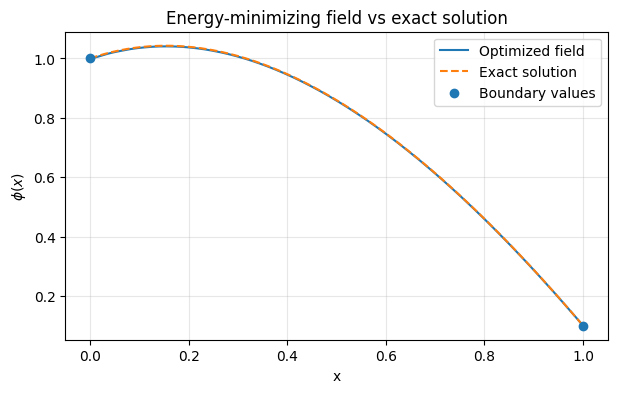

In [12]:
phi_opt = phi_hat(x_plot, theta_opt)
phi_ref = phi_exact(x_plot)
plt.figure(figsize=(7,4))
plt.plot(x_plot, phi_opt, label="Optimized field")
plt.plot(x_plot, phi_ref, "--", label="Exact solution")
plt.scatter([0.0, 1.0], [phi_left, phi_right], zorder=3, label="Boundary values")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Energy-minimizing field vs exact solution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [13]:
max_err = jnp.max(jnp.abs(phi_opt - phi_ref))
print("Max abs error =", float(max_err))


Max abs error = 0.002884838280198254


## Residual check

After deterministic minimization, the optimized field is checked against the differential equation residual

\[
r(x) = -D\phi''(x) - q(x).
\]

A small residual across the domain indicates that the optimized field satisfies the governing equation, not merely that it visually resembles the reference solution.


Residual L2 norm  = 0.7976689162994142
Residual max norm = 5.057027737377618


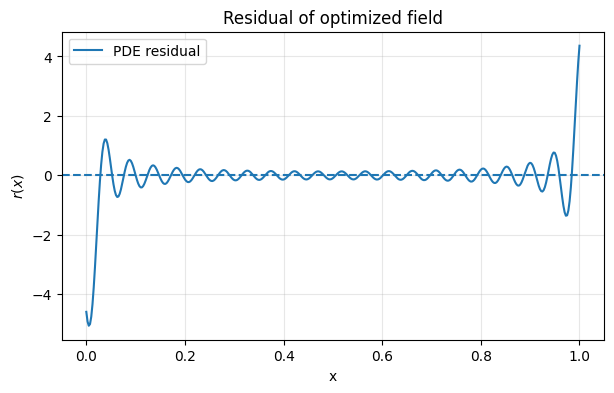

In [14]:
def d2phi_dx2(x, theta):
    """
    Computes d^2(phi)/dx^2 using JAX automatic differentiation.
    """
    def phi_single(x_scalar):
        return phi_hat(jnp.array([x_scalar]), theta)[0]
    return jax.vmap(jax.grad(jax.grad(phi_single)))(x)
def pde_residual(x, theta):
    return -D * d2phi_dx2(x, theta) - q_source(x)
res_opt = pde_residual(x_plot, theta_opt)
print("Residual L2 norm  =", float(jnp.sqrt(jnp.mean(res_opt**2))))
print("Residual max norm =", float(jnp.max(jnp.abs(res_opt))))
plt.figure(figsize=(7,4))
plt.plot(x_plot, res_opt, label="PDE residual")
plt.axhline(0.0, linestyle="--")
plt.xlabel("x")
plt.ylabel(r"$r(x)$")
plt.title("Residual of optimized field")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## SGLD sampling from the physics-informed density
The PIFT prior over the finite-dimensional coefficients is:

$$p(\theta \mid \beta) \propto \exp[-\beta U(\theta)]$$

where $\beta > 0$ controls the strength of trust in the physics. Samples are generated using **Stochastic Gradient Langevin Dynamics**:

$$\theta_{k+1} = \theta_k - \eta \beta \nabla_\theta U(\theta_k) + \sqrt{2\eta}\xi_k, \qquad \xi_k \sim \mathcal{N}(0,I)$$

The chain is initialized near the deterministic minimizer so that sampling begins in a physically meaningful region of parameter space.

In [15]:
def neg_log_target(theta, beta):
    return beta * energy_U(theta)
neg_log_target_grad = jax.jit(jax.grad(neg_log_target, argnums=0))


## SGLD sampler

The sampler below runs a fixed-step SGLD chain and returns retained coefficient samples and an energy trace. The retained samples are used to construct pointwise predictive summaries of the field.


In [16]:
def sgld_sampler(theta_init, beta, step_size=1e-6, n_burn=3000, n_samples=1000, thin=10, seed=0):
    key = jax.random.PRNGKey(seed)
    theta = theta_init.copy()
    samples = []
    energy_trace = []
    total_steps = n_burn + n_samples * thin
    for k in range(total_steps):
        key, subkey = jax.random.split(key)
        noise = jax.random.normal(subkey, shape=theta.shape)
        grad = neg_log_target_grad(theta, beta)
        theta = theta - step_size * grad + jnp.sqrt(2.0 * step_size) * noise
        if k >= n_burn and (k - n_burn) % thin == 0:
            samples.append(theta)
            energy_trace.append(energy_U(theta))
    return jnp.stack(samples), jnp.array(energy_trace)


## Single-chain diagnostic run

A representative value of \(\beta\) is used first to verify numerical stability before performing the full \(\beta\)-sweep.


In [17]:
beta = 20.0
key = jax.random.PRNGKey(123)
theta_init_sgld = theta_opt + 0.01 * jax.random.normal(key, shape=theta_opt.shape)
samples, energy_trace = sgld_sampler(
    theta_init=theta_init_sgld,
    beta=beta,
    step_size=1e-6,
    n_burn=3000,
    n_samples=800,
    thin=20,
    seed=1,
)
print("samples shape:", samples.shape)
print("mean sampled energy:", float(jnp.mean(energy_trace)))
print("std sampled energy :", float(jnp.std(energy_trace)))


samples shape: (800, 41)
mean sampled energy: 0.5036380262647154
std sampled energy : 0.1873868247135869


## Energy trace diagnostic

A stable SGLD chain should produce an energy trace that fluctuates within a bounded range rather than diverging.


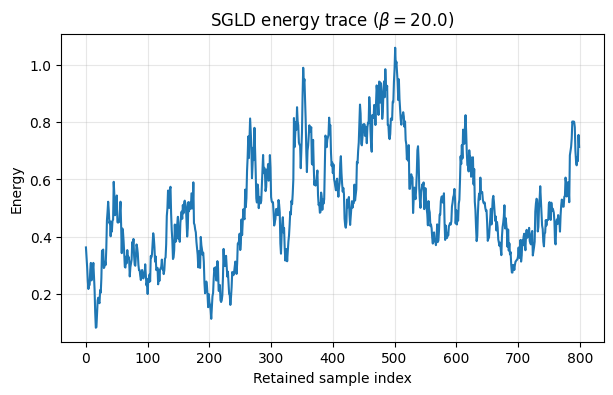

In [18]:
plt.figure(figsize=(7,4))
plt.plot(energy_trace)
plt.xlabel("Retained sample index")
plt.ylabel("Energy")
plt.title(fr"SGLD energy trace ($\beta={beta}$)")
plt.grid(True, alpha=0.3)
plt.show()


## Field samples from retained coefficients

Each retained parameter vector defines a field \(\hat{\phi}(x;\theta)\). These fields are used to compute the sample mean and pointwise uncertainty bands.


In [19]:
phi_samples = jax.vmap(lambda th: phi_hat(x_plot, th))(samples)
phi_mean = jnp.mean(phi_samples, axis=0)
phi_p05 = jnp.percentile(phi_samples, 5.0, axis=0)
phi_p95 = jnp.percentile(phi_samples, 95.0, axis=0)
print("phi_samples shape:", phi_samples.shape)


phi_samples shape: (800, 400)


## Sampled fields and uncertainty band

This diagnostic plot shows sampled fields, the sample mean, a pointwise uncertainty band, and the analytical reference solution.


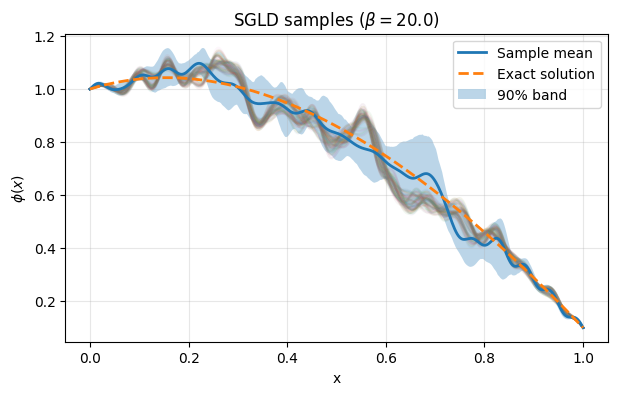

In [20]:
plt.figure(figsize=(7,4))
n_show = min(100, phi_samples.shape[0])
for i in range(n_show):
    plt.plot(x_plot, phi_samples[i], alpha=0.06)
plt.plot(x_plot, phi_mean, linewidth=2, label="Sample mean")
plt.plot(x_plot, phi_ref, "--", linewidth=2, label="Exact solution")
plt.fill_between(x_plot, phi_p05, phi_p95, alpha=0.3, label="90% band")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title(fr"SGLD samples ($\beta={beta}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Inverse-temperature sweep for Example 5.1

The SGLD procedure is repeated for multiple values of \(\beta\). As \(\beta\) increases, the distribution concentrates more strongly around low-energy fields, reproducing the qualitative behavior reported in the paper.


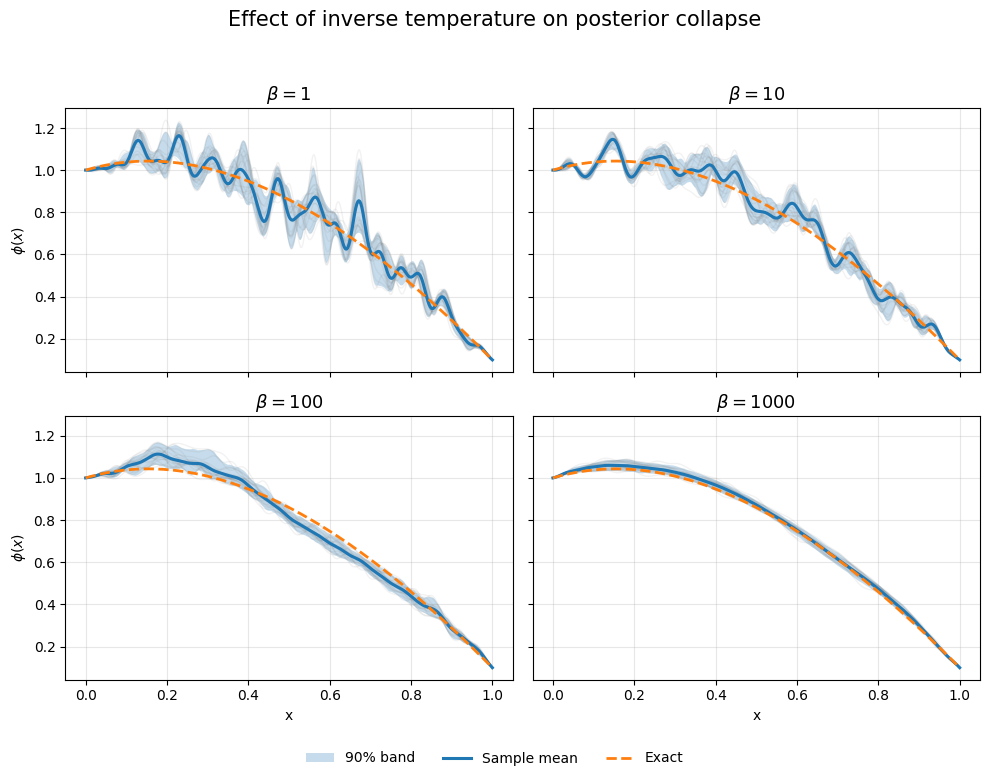

In [21]:
import matplotlib.pyplot as plt
import numpy as np
beta_list = [1, 10, 100, 1000]
beta_results = {}
for beta in beta_list:
    samples_beta, energy_trace_beta = sgld_sampler(
        theta_init=theta_init_sgld,
        beta=beta,
        step_size=1e-6,
        n_burn=3000,
        n_samples=600,
        thin=20,
        seed=int(beta * 10) + 1,
    )
    phi_samples_beta = jax.vmap(lambda th: phi_hat(x_plot, th))(samples_beta)
    beta_results[beta] = {
        "phi_samples": np.array(phi_samples_beta),
        "phi_mean": np.array(jnp.mean(phi_samples_beta, axis=0)),
        "phi_p05": np.array(jnp.percentile(phi_samples_beta, 5.0, axis=0)),
        "phi_p95": np.array(jnp.percentile(phi_samples_beta, 95.0, axis=0)),
    }
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, beta in zip(axes, beta_list):
    res = beta_results[beta]
    phi_samples = res["phi_samples"]
    n_show = min(20, phi_samples.shape[0])
    idx = np.linspace(0, phi_samples.shape[0] - 1, n_show, dtype=int)
    for i in idx:
        ax.plot(x_plot, phi_samples[i], color="gray", alpha=0.10, linewidth=1.0)
    ax.fill_between(
        x_plot,
        res["phi_p05"],
        res["phi_p95"],
        alpha=0.25,
        label="90% band"
    )
    ax.plot(x_plot, res["phi_mean"], linewidth=2.2, label="Sample mean")
    ax.plot(x_plot, phi_ref, "--", linewidth=2.0, label="Exact")
    ax.set_title(fr"$\beta = {beta}$", fontsize=13)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel(r"$\phi(x)$")
axes[2].set_ylabel(r"$\phi(x)$")
axes[2].set_xlabel("x")
axes[3].set_xlabel("x")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02))
fig.suptitle("Effect of inverse temperature on posterior collapse", fontsize=15)
fig.tight_layout(rect=[0, 0.07, 1, 0.95])
fig.savefig("pift_beta_sweep_checkpoint.png", dpi=300, bbox_inches="tight")
fig.savefig("pift_beta_sweep_checkpoint.pdf", bbox_inches="tight")
plt.show()


In [22]:
fig.savefig("pift_beta_sweep_checkpoint.svg", format="svg", bbox_inches="tight")


# Replication note for Example 5.3

Example 5.3 is a stochastic nested-SGLD experiment. The paper does not provide the exact random seed or complete chain state, so an independent implementation is not expected to reproduce the posterior cloud point-for-point.

The replication target is the qualitative structure of the result:

* $D$ should concentrate tightly near the truth $D=0.1$.
* $\kappa$ is less identifiable and can shift between runs because it mixes slowly.
* The posterior predictive field should match the noisy observations and the reference solution.
* In Example 5.3b, the source term is inferred under a GP/KLE prior, making $D$, $\kappa$, and $f(x)$ jointly less identifiable from field observations alone.

## Example 5.3: Nonlinear inverse problems
Example 5.3 uses the nonlinear boundary-value problem:

$$D\phi''(x) - \kappa\phi^3(x) = f(x), \qquad \phi(0)=\phi(1)=0$$

Two inverse problems are considered:
1. **Example 5.3a:** Infer $D$ and $\kappa$ with known source term $f(x)=\cos(4x)$.
2. **Example 5.3b:** Infer $D$, $\kappa$, and the unknown source term $f(x)$.

The inverse temperature is fixed at $\beta=10^5$. Positive parameters are sampled in log-space:

$$\eta_D = \log D, \qquad \eta_\kappa = \log \kappa$$

In [23]:
import numpy as np
from scipy.integrate import solve_bvp
from scipy.optimize import minimize
D_true = 0.1
kappa_true = 1.0
phi0_nl = 0.0
phi1_nl = 0.0
theta_dim = 1 + 2*K
x_nl = jnp.linspace(0.0, 1.0, 400)
def f_true_np(x):
    return np.cos(4.0 * x)
def f_true(x):
    return jnp.cos(4.0 * x)


## Boundary-constrained parameterization for the nonlinear examples

The nonlinear examples use homogeneous boundary conditions. The field is therefore represented as:

$$\hat{\phi}(x;\theta) = (1-x)x \psi(x;\theta)$$

which enforces $\hat{\phi}(0;\theta) = \hat{\phi}(1;\theta) = 0$ exactly.

theta length: 41
phi(0) = 0.0
phi(1) = 0.0


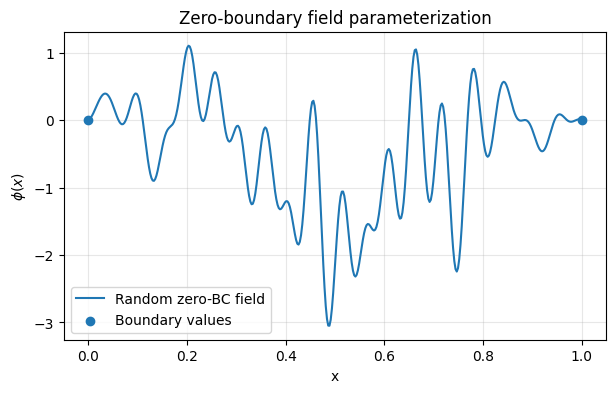

In [24]:
def phi_hat_zero_bc(x, theta):
    """
    Boundary-constrained field for Examples 5.2 and 5.3.
    The boundary conditions phi(0)=phi(1)=0 are satisfied exactly.
    """
    x = jnp.atleast_1d(x)
    return (1.0 - x) * x * psi(x, theta)
def dphi_zero_dx(x, theta):
    """Derivative of the zero-boundary field using JAX automatic differentiation."""
    def phi_single(x_scalar):
        return phi_hat_zero_bc(jnp.array([x_scalar]), theta)[0]
    return jax.vmap(jax.grad(phi_single))(x)
key = jax.random.PRNGKey(520)
theta_test_nl = jax.random.normal(key, shape=(theta_dim,))
print("theta length:", theta_test_nl.shape[0])
print("phi(0) =", float(phi_hat_zero_bc(jnp.array([0.0]), theta_test_nl)[0]))
print("phi(1) =", float(phi_hat_zero_bc(jnp.array([1.0]), theta_test_nl)[0]))
plt.figure(figsize=(7, 4))
plt.plot(x_nl, phi_hat_zero_bc(x_nl, theta_test_nl), label="Random zero-BC field")
plt.scatter([0.0, 1.0], [0.0, 0.0], zorder=3, label="Boundary values")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Zero-boundary field parameterization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Reference nonlinear solution

The reference solution is computed with `solve_bvp`. It is used to generate synthetic observations and to evaluate whether the posterior predictive field is centered near the correct solution.


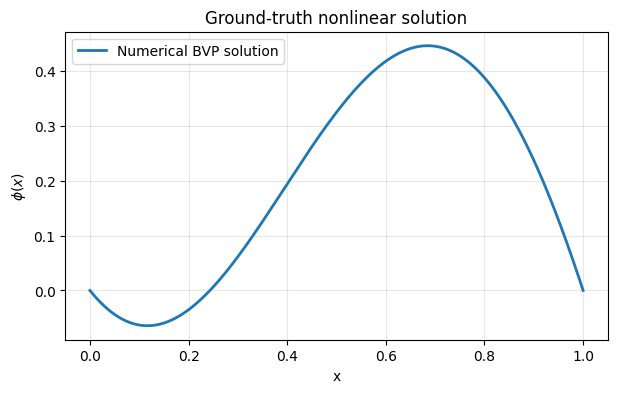

In [25]:
def solve_nonlinear_bvp(D=D_true, kappa=kappa_true, f_np=f_true_np, n_grid=500):
    """
    Solve D phi'' = kappa phi^3 + f(x) with phi(0)=phi(1)=0.
    Returns the scipy solve_bvp result object.
    """
    x_grid = np.linspace(0.0, 1.0, n_grid)
    y_init = np.zeros((2, n_grid))
    def rhs(x, y):
        return np.vstack((y[1], (kappa * y[0]**3 + f_np(x)) / D))
    def bc(ya, yb):
        return np.array([ya[0] - phi0_nl, yb[0] - phi1_nl])
    sol = solve_bvp(rhs, bc, x_grid, y_init, tol=1e-5, max_nodes=10000)
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol
sol_true = solve_nonlinear_bvp()
phi_true_nl = jnp.array(sol_true.sol(np.asarray(x_nl))[0])
plt.figure(figsize=(7, 4))
plt.plot(x_nl, phi_true_nl, linewidth=2, label="Numerical BVP solution")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Ground-truth nonlinear solution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Deterministic energy verification

Before running the inverse sampler, the nonlinear energy is minimized directly. Agreement between the energy minimizer and the numerical BVP solution verifies that the energy functional and parameterization are implemented consistently.


Energy optimization success: True
Final energy: -0.07839571514471805
RMSE vs BVP truth: 0.005214513856545443


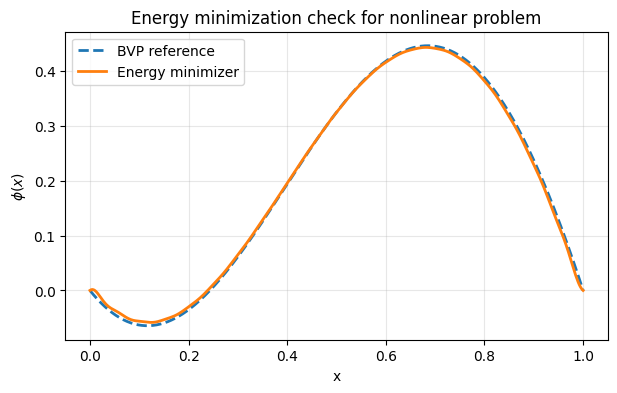

In [26]:
def integrate_on_unit_interval(values, x=x_nl):
    """Simple fixed-grid integration on [0,1]."""
    dx = x[1] - x[0]
    return jnp.sum(values) * dx
def energy_nonlinear_correct(theta, D=D_true, kappa=kappa_true):
    phi_vals = phi_hat_zero_bc(x_nl, theta)
    dphi_vals = dphi_zero_dx(x_nl, theta)
    integrand = 0.5 * D * dphi_vals**2 + 0.25 * kappa * phi_vals**4 + phi_vals * f_true(x_nl)
    return integrate_on_unit_interval(integrand)
def scipy_minimize_jax(fun, theta0, maxiter=800):
    """Convenience wrapper for L-BFGS-B using JAX value-and-gradient."""
    value_and_grad = jax.jit(jax.value_and_grad(fun))
    def obj_np(theta_np):
        val, grad = value_and_grad(jnp.asarray(theta_np))
        return float(val), np.asarray(grad, dtype=float)
    res = minimize(
        fun=lambda th: obj_np(th)[0],
        x0=np.asarray(theta0, dtype=float),
        jac=lambda th: obj_np(th)[1],
        method="L-BFGS-B",
        options={"maxiter": maxiter, "ftol": 1e-10, "gtol": 1e-8},
    )
    return jnp.asarray(res.x), res
key = jax.random.PRNGKey(521)
theta0_nl = 0.05 * jax.random.normal(key, shape=(theta_dim,))
theta_energy_min, res_energy_min = scipy_minimize_jax(energy_nonlinear_correct, theta0_nl)
phi_energy_min = phi_hat_zero_bc(x_nl, theta_energy_min)
rmse_energy = jnp.sqrt(jnp.mean((phi_energy_min - phi_true_nl)**2))
print("Energy optimization success:", res_energy_min.success)
print("Final energy:", float(energy_nonlinear_correct(theta_energy_min)))
print("RMSE vs BVP truth:", float(rmse_energy))
plt.figure(figsize=(7, 4))
plt.plot(x_nl, phi_true_nl, "--", linewidth=2, label="BVP reference")
plt.plot(x_nl, phi_energy_min, linewidth=2, label="Energy minimizer")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Energy minimization check for nonlinear problem")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Synthetic observations

Following the paper setup, 40 interior observations are generated from the reference field and corrupted with independent Gaussian noise.


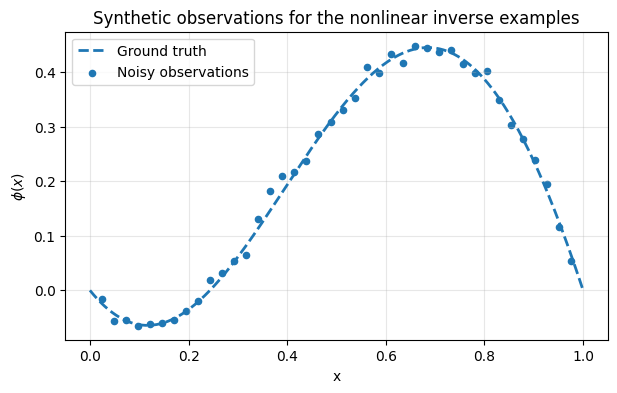

In [27]:
key = jax.random.PRNGKey(522)
n_obs_nl = 40
sigma_nl = 0.012  # paper value: Gaussian noise standard deviation
x_obs_nl = jnp.linspace(0.0, 1.0, n_obs_nl + 2)[1:-1]
phi_obs_clean_nl = jnp.array(sol_true.sol(np.asarray(x_obs_nl))[0])
key, subkey = jax.random.split(key)
y_obs_nl = phi_obs_clean_nl + sigma_nl * jax.random.normal(subkey, shape=x_obs_nl.shape)
plt.figure(figsize=(7, 4))
plt.plot(x_nl, phi_true_nl, "--", linewidth=2, label="Ground truth")
plt.scatter(x_obs_nl, y_obs_nl, s=20, label="Noisy observations")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Synthetic observations for the nonlinear inverse examples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [28]:
def neg_log_likelihood_nl(theta):
    """Gaussian negative log-likelihood at the 40 noisy observations."""
    pred = phi_hat_zero_bc(x_obs_nl, theta)
    return 0.5 * jnp.sum(((pred - y_obs_nl) / sigma_nl) ** 2)


In [29]:
def dpsi_dx_analytic(x, theta):
    """Analytic d/dx of the truncated Fourier series psi."""
    a_cos = theta[1:K + 1]
    b_sin = theta[K + 1:2 * K + 1]
    j = jnp.arange(1, K + 1, dtype=jnp.float64)
    x = jnp.atleast_1d(x)
    dcos = -2.0 * jnp.pi * j[None, :] * jnp.sin(2.0 * jnp.pi * j[None, :] * x[:, None])
    dsin =  2.0 * jnp.pi * j[None, :] * jnp.cos(2.0 * jnp.pi * j[None, :] * x[:, None])
    return jnp.sum(a_cos[None, :] * dcos + b_sin[None, :] * dsin, axis=1)
def dphi_zero_dx_fast(x, theta):
    """
    Analytic d/dx of the zero-BC field:
        phi(x;theta) = (1-x)*x * psi(x;theta)
    d/dx = (1-2x)*psi + (1-x)*x*(dpsi/dx)
    """
    x = jnp.atleast_1d(x)
    psi_v  = psi(x, theta)
    dpsi_v = dpsi_dx_analytic(x, theta)
    return (1.0 - 2.0 * x) * psi_v + (1.0 - x) * x * dpsi_v
key_chk = jax.random.PRNGKey(900)
theta_chk = 0.1 * jax.random.normal(key_chk, shape=(theta_dim,))
x_chk = jnp.linspace(0.01, 0.99, 10)
dphi_ad  = dphi_zero_dx(x_chk, theta_chk)
dphi_ana = dphi_zero_dx_fast(x_chk, theta_chk)
print("Max |analytic - AD| derivative error:", float(jnp.max(jnp.abs(dphi_ad - dphi_ana))))


Max |analytic - AD| derivative error: 1.7763568394002505e-15


In [30]:
import time, numpy as np
LR_FIELD_PRIOR = 1e-7
LR_FIELD_POST  = 5e-8
T_PRIOR = 10
T_POST  = 5
N_WARMUP = 50_000
N_OUTER  = 200_000
ALPHA0_D = 2.0e-6
ALPHA0_K = 8.0e-6
ALPHA0_W = 1.0e-5     # KLE source weights in 5.3b
GAMMA_RM = 0.51
N_FIELD_SNAPSHOTS = 300
COLLECT_EVERY = max(1, N_OUTER // N_FIELD_SNAPSHOTS)
print("Nested SGLD settings for paper-style Example 5.3 replication")
print(f"  Warmup field steps per chain : {N_WARMUP:,}")
print(f"  Outer parameter iterations   : {N_OUTER:,}")
print(f"  Inner steps per outer update : T_prior={T_PRIOR}, T_post={T_POST}")
print(f"  Outer decay                  : eps_t = alpha0/(t+1)^{GAMMA_RM}")
print(f"  alpha0_D={ALPHA0_D:g}, alpha0_kappa={ALPHA0_K:g}, alpha0_w={ALPHA0_W:g}")
print(f"  Total approximate field steps: {N_WARMUP*2 + N_OUTER*(T_PRIOR+T_POST):,}")


Nested SGLD settings for paper-style Example 5.3 replication
  Warmup field steps per chain : 50,000
  Outer parameter iterations   : 200,000
  Inner steps per outer update : T_prior=10, T_post=5
  Outer decay                  : eps_t = alpha0/(t+1)^0.51
  alpha0_D=2e-06, alpha0_kappa=8e-06, alpha0_w=1e-05
  Total approximate field steps: 3,100,000


## Example 5.3a: inference of \(D\) and \(\kappa\)

In this case the source term is known, and the inverse problem estimates \(D\), \(\kappa\), and the latent field coefficients from noisy observations.

The nested sampler maintains two field chains at each parameter value:

- a physics-only prior chain,
- a data-conditioned posterior chain.

The outer parameter update uses the difference between posterior and prior expected energy gradients, following the inverse-problem formulation in the paper. The saved figures reproduce the same panel structure as Fig. 3 of the paper: parameter traces, joint posterior contours, fitted prior predictive samples, and posterior predictive samples.


In [31]:
beta_fixed_53 = 1.0e5
sigma2_nl     = sigma_nl ** 2
@jax.jit
def energy_parametric_53a(theta_field, logD, logkappa):
    D_     = jnp.exp(logD)
    kappa_ = jnp.exp(logkappa)
    phi_v  = phi_hat_zero_bc(x_nl, theta_field)
    dphi_v = dphi_zero_dx_fast(x_nl, theta_field)
    intgrd = (0.5 * D_ * dphi_v**2
              + 0.25 * kappa_ * phi_v**4
              + phi_v * f_true(x_nl))
    return integrate_on_unit_interval(intgrd)
@jax.jit
def prior_step_53a(theta, logD, logkappa, key):
    key, sk = jax.random.split(key)
    g = jax.grad(lambda th: beta_fixed_53 * energy_parametric_53a(th, logD, logkappa))(theta)
    eps = jax.random.normal(sk, shape=theta.shape)
    return theta - LR_FIELD_PRIOR * g + jnp.sqrt(2.0 * LR_FIELD_PRIOR) * eps, key
@jax.jit
def post_step_53a(theta, logD, logkappa, key):
    key, sk = jax.random.split(key)
    def H(th):
        return neg_log_likelihood_nl(th) + beta_fixed_53 * energy_parametric_53a(th, logD, logkappa)
    g = jax.grad(H)(theta)
    eps = jax.random.normal(sk, shape=theta.shape)
    return theta - LR_FIELD_POST * g + jnp.sqrt(2.0 * LR_FIELD_POST) * eps, key
@jax.jit
def param_step_53a(theta_pr, theta_po, logD, logkappa, epsD, epsK, key):
    """
    Outer SGLD step for log(D), log(kappa).
    Eq. (26) in the paper: posterior expectation minus prior expectation.
    The step sizes epsD and epsK are dynamic Robbins–Monro values.
    """
    def U_diff(ld, lk):
        return beta_fixed_53 * (
            energy_parametric_53a(theta_po, ld, lk)
            - energy_parametric_53a(theta_pr, ld, lk)
        )
    g_ld, g_lk = jax.grad(U_diff, argnums=(0, 1))(logD, logkappa)
    key, sk1, sk2 = jax.random.split(key, 3)
    logD_new = jnp.clip(
        logD - epsD * g_ld + jnp.sqrt(2.0 * epsD) * jax.random.normal(sk1),
        jnp.log(1e-3), jnp.log(10.0)
    )
    logk_new = jnp.clip(
        logkappa - epsK * g_lk + jnp.sqrt(2.0 * epsK) * jax.random.normal(sk2),
        jnp.log(1e-3), jnp.log(10.0)
    )
    return logD_new, logk_new, key
@jax.jit
def warmup_prior_53a(theta, logD, logkappa, key):
    def step(carry, _):
        th, ld, lk, k = carry
        k, sk = jax.random.split(k)
        g = jax.grad(lambda t: beta_fixed_53 * energy_parametric_53a(t, ld, lk))(th)
        eps = jax.random.normal(sk, shape=th.shape)
        return (th - LR_FIELD_PRIOR * g + jnp.sqrt(2.0 * LR_FIELD_PRIOR) * eps, ld, lk, k), None
    (th_out, _, _, k_out), _ = jax.lax.scan(step, (theta, logD, logkappa, key), None, length=N_WARMUP)
    return th_out, k_out
@jax.jit
def warmup_post_53a(theta, logD, logkappa, key):
    def step(carry, _):
        th, ld, lk, k = carry
        k, sk = jax.random.split(k)
        def H(t):
            return neg_log_likelihood_nl(t) + beta_fixed_53 * energy_parametric_53a(t, ld, lk)
        g = jax.grad(H)(th)
        eps = jax.random.normal(sk, shape=th.shape)
        return (th - LR_FIELD_POST * g + jnp.sqrt(2.0 * LR_FIELD_POST) * eps, ld, lk, k), None
    (th_out, _, _, k_out), _ = jax.lax.scan(step, (theta, logD, logkappa, key), None, length=N_WARMUP)
    return th_out, k_out
print("5.3a JIT functions defined.")


5.3a JIT functions defined.


In [32]:
key_53a = jax.random.PRNGKey(530)
logD_init     = jnp.array(jnp.log(0.20), dtype=jnp.float64)   # off-truth, still explores D
logkappa_init = jnp.array(jnp.log(1.00), dtype=jnp.float64)   # nominal kappa for paper-style run
theta_init_53a = theta_energy_min + 0.01 * jax.random.normal(key_53a, shape=(theta_dim,))
print("Compiling and running 5.3a field warmup ...")
key_53a, k1, k2 = jax.random.split(key_53a, 3)
t0 = time.time()
theta_pr_53a, _ = warmup_prior_53a(theta_init_53a, logD_init, logkappa_init, k1)
theta_pr_53a.block_until_ready()
print(f"  Prior warmup done in {time.time()-t0:.1f} s")
t0 = time.time()
theta_po_53a, _ = warmup_post_53a(theta_init_53a, logD_init, logkappa_init, k2)
theta_po_53a.block_until_ready()
print(f"  Posterior warmup done in {time.time()-t0:.1f} s")
print(f"\nRunning {N_OUTER:,} outer SGLD iterations for 5.3a ...")
logD     = logD_init
logkappa = logkappa_init
key_run  = jax.random.PRNGKey(531)
logD_hist, logk_hist = [], []
theta_post_list = []
t_start = time.time()
for t in range(N_OUTER):
    for _ in range(T_PRIOR):
        theta_pr_53a, key_run = prior_step_53a(theta_pr_53a, logD, logkappa, key_run)
    for _ in range(T_POST):
        theta_po_53a, key_run = post_step_53a(theta_po_53a, logD, logkappa, key_run)
    epsD = ALPHA0_D / ((t + 1) ** GAMMA_RM)
    epsK = ALPHA0_K / ((t + 1) ** GAMMA_RM)
    logD, logkappa, key_run = param_step_53a(
        theta_pr_53a, theta_po_53a, logD, logkappa, epsD, epsK, key_run
    )
    logD_hist.append(float(logD))
    logk_hist.append(float(logkappa))
    if (t + 1) % COLLECT_EVERY == 0:
        theta_post_list.append(np.array(theta_po_53a))
    if (t + 1) % max(1, N_OUTER // 10) == 0:
        print(f"  iter {t+1:6d}/{N_OUTER}  "
              f"D={float(jnp.exp(logD)):.4f}  kappa={float(jnp.exp(logkappa)):.4f}  "
              f"({time.time()-t_start:.0f} s)", flush=True)
print(f"\nTotal 5.3a wall time: {time.time()-t_start:.1f} s")
logD_arr_53a      = jnp.array(logD_hist)
logk_arr_53a      = jnp.array(logk_hist)
D_samples_53a     = jnp.exp(logD_arr_53a)
kappa_samples_53a = jnp.exp(logk_arr_53a)
theta_samples_53a = jnp.array(theta_post_list)
half = N_OUTER // 2
print(f"\nPosterior summary 5.3a, last {N_OUTER-half:,} samples")
print(f"  D     median = {float(jnp.median(D_samples_53a[half:])):.4f}  (truth {D_true:.2f})")
print(f"  kappa median = {float(jnp.median(kappa_samples_53a[half:])):.4f}  (truth {kappa_true:.2f})")
print(f"  D     mean   = {float(jnp.mean(D_samples_53a[half:])):.4f} ± {float(jnp.std(D_samples_53a[half:])):.4f}")
print(f"  kappa mean   = {float(jnp.mean(kappa_samples_53a[half:])):.4f} ± {float(jnp.std(kappa_samples_53a[half:])):.4f}")


Compiling and running 5.3a field warmup ...
  Prior warmup done in 4.0 s
  Posterior warmup done in 5.1 s

Running 200,000 outer SGLD iterations for 5.3a ...
  iter  20000/200000  D=0.1070  kappa=0.8584  (40 s)
  iter  40000/200000  D=0.1029  kappa=0.7745  (75 s)
  iter  60000/200000  D=0.1007  kappa=0.8312  (110 s)
  iter  80000/200000  D=0.0989  kappa=0.8120  (145 s)
  iter 100000/200000  D=0.1006  kappa=0.7934  (181 s)
  iter 120000/200000  D=0.0981  kappa=0.7841  (217 s)
  iter 140000/200000  D=0.0996  kappa=0.8116  (254 s)
  iter 160000/200000  D=0.1001  kappa=0.8490  (289 s)
  iter 180000/200000  D=0.0993  kappa=0.8579  (325 s)
  iter 200000/200000  D=0.0996  kappa=0.8374  (359 s)

Total 5.3a wall time: 359.0 s

Posterior summary 5.3a, last 100,000 samples
  D     median = 0.0994  (truth 0.10)
  kappa median = 0.8369  (truth 1.00)
  D     mean   = 0.0993 ± 0.0009
  kappa mean   = 0.8292 ± 0.0245


Solving 60 BVPs for fitted prior predictive ...
  Successful: 60 / 60


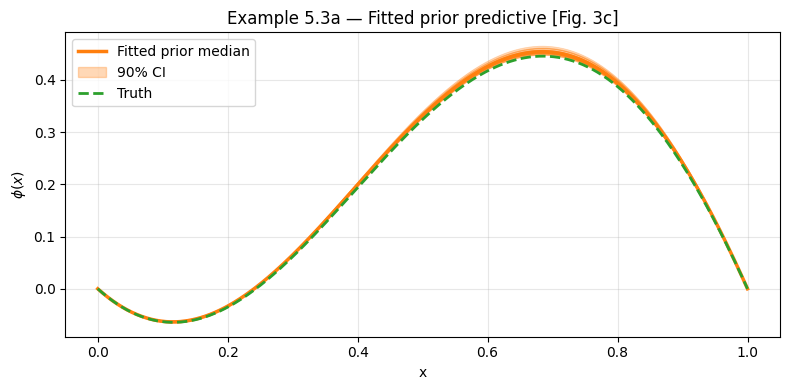

In [33]:
from scipy.integrate import solve_bvp
import numpy as np # Ensure numpy is imported
def bvp_solve_53a(D_val, kappa_val, n_grid=250):
    """Solve D phi\'\' = kappa phi^3 + cos(4x), phi(0)=phi(1)=0."""
    x_g = np.linspace(0.0, 1.0, n_grid)
    y0  = np.zeros((2, n_grid))
    def rhs(x, y): return np.vstack((y[1], (kappa_val * y[0]**3 + f_true_np(x)) / D_val))
    def bc(ya, yb): return np.array([ya[0], yb[0]])
    sol = solve_bvp(rhs, bc, x_g, y0, tol=1e-4, max_nodes=5000)
    return sol.sol(np.asarray(x_nl))[0] if sol.success else None
D_np    = np.asarray(D_samples_53a)
kap_np  = np.asarray(kappa_samples_53a)
logD_np = np.asarray(logD_arr_53a)
logk_np = np.asarray(logk_arr_53a)
half    = N_OUTER // 2
x_np = np.asarray(x_nl)
N_BVP = 60
D_post   = D_np[half:]
kap_post = kap_np[half:]
stride   = max(1, len(D_post) // N_BVP)
idx_pp   = np.arange(0, len(D_post), stride)[:N_BVP]
print(f"Solving {len(idx_pp)} BVPs for fitted prior predictive ...")
fpp_fields = []
for ii in idx_pp:
    field = bvp_solve_53a(float(D_post[ii]), float(kap_post[ii]))
    if field is not None:
        fpp_fields.append(field)
fpp_fields = np.array(fpp_fields)
print(f"  Successful: {len(fpp_fields)} / {len(idx_pp)}")
fpp_med = np.percentile(fpp_fields, 50, axis=0)
fpp_lo  = np.percentile(fpp_fields, 5,  axis=0)
fpp_hi  = np.percentile(fpp_fields, 95, axis=0)
plt.figure(figsize=(8, 4))
for i in range(min(40, fpp_fields.shape[0])):
    plt.plot(x_np, fpp_fields[i], lw=0.5, alpha=0.3, color="C1")
plt.plot(x_np, fpp_med, lw=2.5, color="C1", label="Fitted prior median")
plt.fill_between(x_np, fpp_lo, fpp_hi, alpha=0.3, color="C1", label="90% CI")
plt.plot(x_np, np.asarray(phi_true_nl), "--", lw=2, color="C2", label="Truth")
plt.xlabel("x"); plt.ylabel(r"$\phi(x)$")
plt.title("Example 5.3a — Fitted prior predictive [Fig. 3c]")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


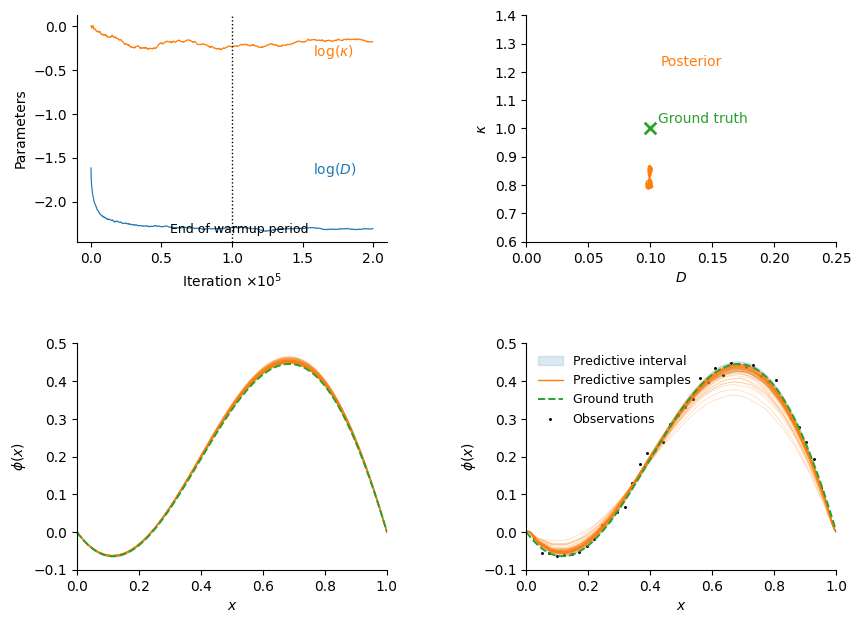

Saved PIFT_Fig3_Example53a_paper_style_v2.svg
D posterior median = 0.0994; kappa posterior median = 0.8369


In [34]:
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
D_np    = np.asarray(D_samples_53a)
kap_np  = np.asarray(kappa_samples_53a)
logD_np = np.asarray(logD_arr_53a)
logk_np = np.asarray(logk_arr_53a)
half    = N_OUTER // 2
x_np = np.asarray(x_nl)
phi_post_53a = jax.vmap(lambda th: phi_hat_zero_bc(x_nl, th))(theta_samples_53a)
phi_post_53a_np = np.asarray(phi_post_53a)
phi_mean_53a = np.mean(phi_post_53a_np, axis=0)
phi_lo_53a   = np.percentile(phi_post_53a_np, 5.0, axis=0)
phi_hi_53a   = np.percentile(phi_post_53a_np, 95.0, axis=0)
D_post = D_np[half:]
K_post = kap_np[half:]
kde_stride = max(1, len(D_post) // 25_000)
D_kde = D_post[::kde_stride]
K_kde = K_post[::kde_stride]
DD, KK, ZZ = None, None, None
try:
    pts = np.vstack([D_kde, K_kde])
    kde = gaussian_kde(pts)
    D_grid = np.linspace(0.0, 0.25, 220)
    K_grid = np.linspace(0.6, 1.4, 220)
    DD, KK = np.meshgrid(D_grid, K_grid)
    ZZ = kde(np.vstack([DD.ravel(), KK.ravel()])).reshape(DD.shape)
except Exception as e:
    print("KDE contour fallback:", repr(e))
fig = plt.figure(figsize=(9.8, 7.2))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.45)
ax = fig.add_subplot(gs[0, 0])
trace_stride = max(1, len(logD_np) // 1200)
iter_axis = np.arange(len(logD_np))[::trace_stride] / 1e5
ax.plot(iter_axis, logk_np[::trace_stride], lw=0.85, color='C1')
ax.plot(iter_axis, logD_np[::trace_stride], lw=0.85, color='C0')
ax.axvline(half / 1e5, color='k', ls=':', lw=1.0)
ax.text(0.76, 0.82, r'$\log(\kappa)$', color='C1', transform=ax.transAxes, fontsize=10)
ax.text(0.76, 0.30, r'$\log(D)$', color='C0', transform=ax.transAxes, fontsize=10)
ax.text(0.30, 0.04, 'End of warmup period', transform=ax.transAxes, fontsize=9)
ax.set_xlabel(r'Iteration $\times 10^5$')
ax.set_ylabel('Parameters')
ax.spines[['top','right']].set_visible(False)
ax = fig.add_subplot(gs[0, 1])
if ZZ is not None and np.all(np.isfinite(ZZ)) and np.nanmax(ZZ) > 0:
    levels = np.linspace(np.nanmax(ZZ) * 0.12, np.nanmax(ZZ) * 0.92, 9)
    ax.contour(DD, KK, ZZ, levels=levels, colors='C1', linewidths=1.0)
else:
    ax.scatter(D_post[::max(1, len(D_post)//4000)], K_post[::max(1, len(K_post)//4000)],
               s=3, alpha=0.15, color='C1')
ax.scatter([D_true], [kappa_true], marker='x', s=70, color='C2', linewidths=2)
ax.text(D_true + 0.006, kappa_true + 0.02, 'Ground truth', color='C2', fontsize=10)
ax.text(0.108, 1.22, 'Posterior', color='C1', fontsize=10)
ax.set_xlim(0.0, 0.25)
ax.set_ylim(0.6, 1.4)
ax.set_xlabel(r'$D$')
ax.set_ylabel(r'$\kappa$')
ax.spines[['top','right']].set_visible(False)
ax = fig.add_subplot(gs[1, 0])
for i in range(min(45, fpp_fields.shape[0])):
    ax.plot(x_np, fpp_fields[i], lw=0.65, alpha=0.35, color='C1')
ax.fill_between(x_np, fpp_lo, fpp_hi, alpha=0.18, color='C0')
ax.plot(x_np, np.asarray(phi_true_nl), '--', lw=1.4, color='C2')
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 0.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\phi(x)$')
ax.spines[['top','right']].set_visible(False)
ax = fig.add_subplot(gs[1, 1])
for i in range(min(60, phi_post_53a_np.shape[0])):
    ax.plot(x_np, phi_post_53a_np[i], lw=0.55, alpha=0.28, color='C1')
ax.fill_between(x_np, phi_lo_53a, phi_hi_53a, alpha=0.16, color='C0', label='Predictive interval')
ax.plot([], [], color='C1', lw=1.0, label='Predictive samples')
ax.plot(x_np, np.asarray(phi_true_nl), '--', lw=1.4, color='C2', label='Ground truth')
ax.scatter(np.asarray(x_obs_nl), np.asarray(y_obs_nl), s=5, color='k', marker='.', label='Observations')
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 0.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\phi(x)$')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.savefig('PIFT_Fig3_Example53a_paper_style_v2.svg', bbox_inches='tight')
plt.show()
print('Saved PIFT_Fig3_Example53a_paper_style_v2.svg')
print(f'D posterior median = {np.median(D_post):.4f}; kappa posterior median = {np.median(K_post):.4f}')


## Example 5.3b: Inference of $D, \kappa,$ and $f(x)$
The source term is now treated as unknown. A squared-exponential Gaussian-process prior with lengthscale $\ell=0.3$ is approximated using a truncated **Karhunen-Loève expansion**:

$$f(x;w) \approx \sum_{m=1}^{M}\sqrt{\lambda_m}e_m(x)w_m, \qquad w_m \sim \mathcal{N}(0,1), \qquad M=10$$

This example is less identifiable than 5.3a because changes in the source term can compensate for changes in $D$ and $\kappa$.

10-mode KLE representation RMSE for cos(4x): 0.00001


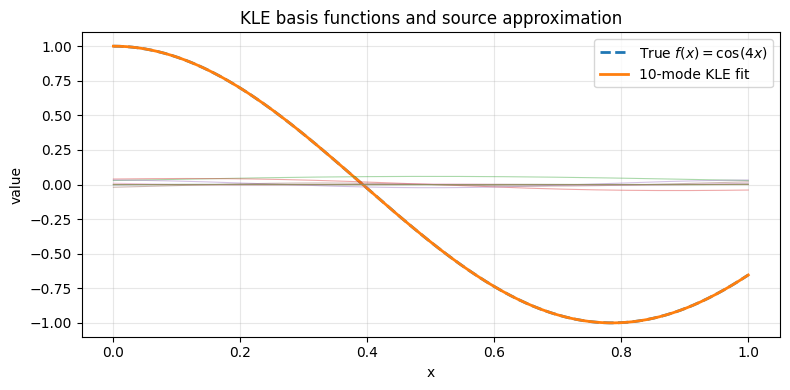

In [35]:
M_kle   = 10
LS_KLE  = 0.30   # paper value: squared-exponential lengthscale
x_kle_np = np.linspace(0.0, 1.0, 250)
def sq_exp(xa, xb, ls=LS_KLE):
    xa = np.asarray(xa)[:, None]
    xb = np.asarray(xb)[None, :]
    return np.exp(-0.5 * ((xa - xb) / ls)**2)
Kcov  = sq_exp(x_kle_np, x_kle_np)
evals, evecs = np.linalg.eigh(Kcov / len(x_kle_np))
order = np.argsort(evals)[::-1]
evals  = evals[order][:M_kle]
evecs  = evecs[:, order][:, :M_kle]
kle_basis_np = evecs * np.sqrt(np.maximum(evals, 0.0))[None, :]
for m in range(M_kle):
    if kle_basis_np[np.argmax(np.abs(kle_basis_np[:, m])), m] < 0:
        kle_basis_np[:, m] *= -1
kle_basis_xnl = np.vstack([
    np.interp(np.asarray(x_nl), x_kle_np, kle_basis_np[:, m])
    for m in range(M_kle)
]).T
kle_basis_jax = jnp.asarray(kle_basis_xnl)
kle_basis_xobs = np.vstack([
    np.interp(np.asarray(x_obs_nl), x_kle_np, kle_basis_np[:, m])
    for m in range(M_kle)
]).T
kle_basis_xobs_jax = jnp.asarray(kle_basis_xobs)
def source_from_kle(w):
    return kle_basis_jax @ w
w_ls, *_ = np.linalg.lstsq(kle_basis_xnl, np.asarray(f_true(x_nl)), rcond=None)
f_kle_approx = kle_basis_xnl @ w_ls
err_kle = float(np.sqrt(np.mean((f_kle_approx - np.asarray(f_true(x_nl)))**2)))
print(f"10-mode KLE representation RMSE for cos(4x): {err_kle:.5f}")
plt.figure(figsize=(8, 4))
plt.plot(x_np, np.asarray(f_true(x_nl)), "--", linewidth=2, label=r"True $f(x)=\cos(4x)$")
plt.plot(x_np, f_kle_approx, linewidth=2, label="10-mode KLE fit")
for m in range(M_kle):
    plt.plot(x_np, kle_basis_xnl[:, m], linewidth=0.8, alpha=0.4)
plt.xlabel("x"); plt.ylabel("value")
plt.title("KLE basis functions and source approximation")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [36]:
@jax.jit
def energy_parametric_53b(theta_field, logD, logkappa, w):
    D_     = jnp.exp(logD)
    kappa_ = jnp.exp(logkappa)
    phi_v  = phi_hat_zero_bc(x_nl, theta_field)
    dphi_v = dphi_zero_dx_fast(x_nl, theta_field)
    f_vals = source_from_kle(w)
    intgrd = (0.5 * D_ * dphi_v**2
              + 0.25 * kappa_ * phi_v**4
              + phi_v * f_vals)
    return integrate_on_unit_interval(intgrd)
@jax.jit
def prior_step_53b(theta, logD, logkappa, w, key):
    key, sk = jax.random.split(key)
    g = jax.grad(lambda th: beta_fixed_53 * energy_parametric_53b(th, logD, logkappa, w))(theta)
    eps = jax.random.normal(sk, shape=theta.shape)
    return theta - LR_FIELD_PRIOR * g + jnp.sqrt(2.0 * LR_FIELD_PRIOR) * eps, key
@jax.jit
def post_step_53b(theta, logD, logkappa, w, key):
    key, sk = jax.random.split(key)
    def H(th):
        return neg_log_likelihood_nl(th) + beta_fixed_53 * energy_parametric_53b(th, logD, logkappa, w)
    g = jax.grad(H)(theta)
    eps = jax.random.normal(sk, shape=theta.shape)
    return theta - LR_FIELD_POST * g + jnp.sqrt(2.0 * LR_FIELD_POST) * eps, key
@jax.jit
def param_step_53b(theta_pr, theta_po, logD, logkappa, w, epsD, epsK, epsW, key):
    """Outer SGLD step for log(D), log(kappa), and KLE source weights."""
    def U_diff(ld, lk, ww):
        return beta_fixed_53 * (
            energy_parametric_53b(theta_po, ld, lk, ww)
            - energy_parametric_53b(theta_pr, ld, lk, ww)
        )
    g_ld, g_lk, g_w = jax.grad(U_diff, argnums=(0, 1, 2))(logD, logkappa, w)
    g_w_total = g_w + w   # Gaussian KLE weight prior: 0.5 ||w||^2
    key, sk1, sk2, sk3 = jax.random.split(key, 4)
    logD_new = jnp.clip(
        logD - epsD * g_ld + jnp.sqrt(2.0 * epsD) * jax.random.normal(sk1),
        jnp.log(1e-3), jnp.log(10.0)
    )
    logk_new = jnp.clip(
        logkappa - epsK * g_lk + jnp.sqrt(2.0 * epsK) * jax.random.normal(sk2),
        jnp.log(1e-3), jnp.log(10.0)
    )
    w_new = w - epsW * g_w_total + jnp.sqrt(2.0 * epsW) * jax.random.normal(sk3, shape=w.shape)
    return logD_new, logk_new, w_new, key
@jax.jit
def warmup_prior_53b(theta, logD, logkappa, w, key):
    def step(carry, _):
        th, ld, lk, ww, k = carry
        k, sk = jax.random.split(k)
        g = jax.grad(lambda t: beta_fixed_53 * energy_parametric_53b(t, ld, lk, ww))(th)
        eps = jax.random.normal(sk, shape=th.shape)
        return (th - LR_FIELD_PRIOR * g + jnp.sqrt(2.0 * LR_FIELD_PRIOR) * eps, ld, lk, ww, k), None
    (th_out, _, _, _, k_out), _ = jax.lax.scan(step, (theta, logD, logkappa, w, key), None, length=N_WARMUP)
    return th_out, k_out
@jax.jit
def warmup_post_53b(theta, logD, logkappa, w, key):
    def step(carry, _):
        th, ld, lk, ww, k = carry
        k, sk = jax.random.split(k)
        def H(t):
            return neg_log_likelihood_nl(t) + beta_fixed_53 * energy_parametric_53b(t, ld, lk, ww)
        g = jax.grad(H)(th)
        eps = jax.random.normal(sk, shape=th.shape)
        return (th - LR_FIELD_POST * g + jnp.sqrt(2.0 * LR_FIELD_POST) * eps, ld, lk, ww, k), None
    (th_out, _, _, _, k_out), _ = jax.lax.scan(step, (theta, logD, logkappa, w, key), None, length=N_WARMUP)
    return th_out, k_out
print("5.3b JIT functions defined.")


5.3b JIT functions defined.


In [37]:
key_53b = jax.random.PRNGKey(540)
key_53b, k1, k2 = jax.random.split(key_53b, 3)
logD_init_b     = jnp.array(jnp.log(0.15), dtype=jnp.float64)
logkappa_init_b = jnp.array(jnp.log(1.00), dtype=jnp.float64)
w_init          = jnp.asarray(w_ls) + 0.02 * jax.random.normal(k1, shape=(M_kle,))
theta_init_53b  = theta_energy_min + 0.01 * jax.random.normal(k2, shape=(theta_dim,))
print("Compiling and running 5.3b field warmup ...")
key_53b, kb1, kb2 = jax.random.split(key_53b, 3)
t0 = time.time()
theta_pr_53b, _ = warmup_prior_53b(theta_init_53b, logD_init_b, logkappa_init_b, w_init, kb1)
theta_pr_53b.block_until_ready()
print(f"  Prior warmup done in {time.time()-t0:.1f} s")
t0 = time.time()
theta_po_53b, _ = warmup_post_53b(theta_init_53b, logD_init_b, logkappa_init_b, w_init, kb2)
theta_po_53b.block_until_ready()
print(f"  Posterior warmup done in {time.time()-t0:.1f} s")
print(f"\nRunning {N_OUTER:,} outer SGLD iterations for 5.3b ...")
logD_b     = logD_init_b
logkappa_b = logkappa_init_b
w_b        = w_init
key_run_b  = jax.random.PRNGKey(541)
logD_hist_b, logk_hist_b = [], []
theta_post_list_b = []
f_samples_list = []
w_hist = []
t_start = time.time()
for t in range(N_OUTER):
    for _ in range(T_PRIOR):
        theta_pr_53b, key_run_b = prior_step_53b(theta_pr_53b, logD_b, logkappa_b, w_b, key_run_b)
    for _ in range(T_POST):
        theta_po_53b, key_run_b = post_step_53b(theta_po_53b, logD_b, logkappa_b, w_b, key_run_b)
    epsD = ALPHA0_D / ((t + 1) ** GAMMA_RM)
    epsK = ALPHA0_K / ((t + 1) ** GAMMA_RM)
    epsW = ALPHA0_W / ((t + 1) ** GAMMA_RM)
    logD_b, logkappa_b, w_b, key_run_b = param_step_53b(
        theta_pr_53b, theta_po_53b, logD_b, logkappa_b, w_b,
        epsD, epsK, epsW, key_run_b
    )
    logD_hist_b.append(float(logD_b))
    logk_hist_b.append(float(logkappa_b))
    if (t + 1) % COLLECT_EVERY == 0:
        theta_post_list_b.append(np.array(theta_po_53b))
        f_samples_list.append(np.array(source_from_kle(w_b)))
        w_hist.append(np.array(w_b))
    if (t + 1) % max(1, N_OUTER // 10) == 0:
        print(f"  iter {t+1:6d}/{N_OUTER}  "
              f"D={float(jnp.exp(logD_b)):.4f}  kappa={float(jnp.exp(logkappa_b)):.4f}  "
              f"({time.time()-t_start:.0f} s)", flush=True)
print(f"\nTotal 5.3b wall time: {time.time()-t_start:.1f} s")
logD_arr_53b      = jnp.array(logD_hist_b)
logk_arr_53b      = jnp.array(logk_hist_b)
D_samples_53b     = jnp.exp(logD_arr_53b)
kappa_samples_53b = jnp.exp(logk_arr_53b)
theta_samples_53b = jnp.array(theta_post_list_b)
f_samples_53b     = jnp.array(f_samples_list)
w_samples_53b     = jnp.array(w_hist)
half_b = N_OUTER // 2
print(f"\nPosterior summary 5.3b, last {N_OUTER-half_b:,} samples")
print(f"  D     median = {float(jnp.median(D_samples_53b[half_b:])):.4f}  (truth {D_true:.2f})")
print(f"  kappa median = {float(jnp.median(kappa_samples_53b[half_b:])):.4f}  (truth {kappa_true:.2f})")


Compiling and running 5.3b field warmup ...
  Prior warmup done in 3.4 s
  Posterior warmup done in 4.4 s

Running 200,000 outer SGLD iterations for 5.3b ...
  iter  20000/200000  D=0.1077  kappa=0.8686  (42 s)
  iter  40000/200000  D=0.1049  kappa=0.8025  (79 s)
  iter  60000/200000  D=0.1020  kappa=0.7785  (117 s)
  iter  80000/200000  D=0.1026  kappa=0.7738  (154 s)
  iter 100000/200000  D=0.1009  kappa=0.7356  (192 s)
  iter 120000/200000  D=0.1001  kappa=0.7556  (229 s)
  iter 140000/200000  D=0.1012  kappa=0.7466  (269 s)
  iter 160000/200000  D=0.1016  kappa=0.7398  (306 s)
  iter 180000/200000  D=0.1016  kappa=0.7296  (345 s)
  iter 200000/200000  D=0.1011  kappa=0.7120  (383 s)

Total 5.3b wall time: 383.1 s

Posterior summary 5.3b, last 100,000 samples
  D     median = 0.1013  (truth 0.10)
  kappa median = 0.7415  (truth 1.00)


Computing fitted prior predictive for 5.3b ...
  Valid BVPs: 45


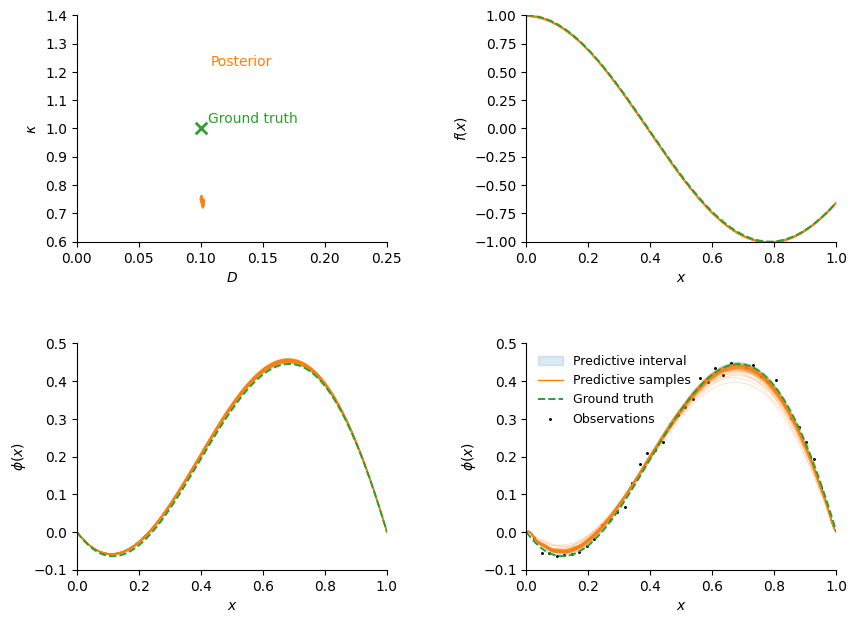

Saved PIFT_Fig4_Example53b_paper_style_v2.svg
D posterior median = 0.1013; kappa posterior median = 0.7415


In [38]:
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
D_np_b   = np.asarray(D_samples_53b)
kap_np_b = np.asarray(kappa_samples_53b)
f_np_b   = np.asarray(f_samples_53b)
half_b   = N_OUTER // 2
x_np     = np.asarray(x_nl)
phi_post_53b = jax.vmap(lambda th: phi_hat_zero_bc(x_nl, th))(theta_samples_53b)
phi_post_53b_np = np.asarray(phi_post_53b)
phi_mean_53b = np.mean(phi_post_53b_np, axis=0)
phi_lo_53b   = np.percentile(phi_post_53b_np, 5.0, axis=0)
phi_hi_53b   = np.percentile(phi_post_53b_np, 95.0, axis=0)
f_mean_53b = np.mean(f_np_b, axis=0)
f_lo_53b   = np.percentile(f_np_b, 5.0, axis=0)
f_hi_53b   = np.percentile(f_np_b, 95.0, axis=0)
print('Computing fitted prior predictive for 5.3b ...')
N_BVP_B = 45
idx_source = np.linspace(max(0, f_np_b.shape[0]//2), f_np_b.shape[0]-1, N_BVP_B).astype(int)
idx_param  = np.linspace(half_b, len(D_np_b)-1, N_BVP_B).astype(int)
fpp_b = []
for isrc, ipar in zip(idx_source, idx_param):
    f_samp = f_np_b[isrc]
    D_val  = float(D_np_b[ipar])
    k_val  = float(kap_np_b[ipar])
    x_g = np.linspace(0.0, 1.0, 250)
    y0 = np.zeros((2, 250))
    def rhs(x, y, D=D_val, k=k_val, f=f_samp):
        fv = np.interp(x, x_np, f)
        return np.vstack((y[1], (k * y[0]**3 + fv) / D))
    sol = solve_bvp(rhs, lambda ya, yb: np.array([ya[0], yb[0]]), x_g, y0,
                    tol=1e-4, max_nodes=5000)
    if sol.success:
        fpp_b.append(sol.sol(x_np)[0])
fpp_b = np.array(fpp_b) if fpp_b else np.zeros((1, len(x_np)))
print(f'  Valid BVPs: {len(fpp_b)}')
fpp_b_med = np.percentile(fpp_b, 50, axis=0)
fpp_b_lo  = np.percentile(fpp_b, 5, axis=0)
fpp_b_hi  = np.percentile(fpp_b, 95, axis=0)
D_post_b = D_np_b[half_b:]
K_post_b = kap_np_b[half_b:]
kde_stride_b = max(1, len(D_post_b) // 25_000)
DD_b, KK_b, ZZ_b = None, None, None
try:
    kde_b = gaussian_kde(np.vstack([D_post_b[::kde_stride_b], K_post_b[::kde_stride_b]]))
    D_grid_b = np.linspace(0.0, 0.25, 220)
    K_grid_b = np.linspace(0.6, 1.4, 220)
    DD_b, KK_b = np.meshgrid(D_grid_b, K_grid_b)
    ZZ_b = kde_b(np.vstack([DD_b.ravel(), KK_b.ravel()])).reshape(DD_b.shape)
except Exception as e:
    print('KDE contour fallback:', repr(e))
fig = plt.figure(figsize=(9.8, 7.2))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.45)
ax = fig.add_subplot(gs[0, 0])
if ZZ_b is not None and np.all(np.isfinite(ZZ_b)) and np.nanmax(ZZ_b) > 0:
    levels_b = np.linspace(np.nanmax(ZZ_b) * 0.12, np.nanmax(ZZ_b) * 0.92, 9)
    ax.contour(DD_b, KK_b, ZZ_b, levels=levels_b, colors='C1', linewidths=1.0)
else:
    ax.scatter(D_post_b[::max(1, len(D_post_b)//4000)], K_post_b[::max(1, len(K_post_b)//4000)],
               s=3, alpha=0.15, color='C1')
ax.scatter([D_true], [kappa_true], marker='x', s=70, color='C2', linewidths=2)
ax.text(D_true + 0.006, kappa_true + 0.02, 'Ground truth', color='C2', fontsize=10)
ax.text(0.108, 1.22, 'Posterior', color='C1', fontsize=10)
ax.set_xlim(0.0, 0.25)
ax.set_ylim(0.6, 1.4)
ax.set_xlabel(r'$D$')
ax.set_ylabel(r'$\kappa$')
ax.spines[['top','right']].set_visible(False)
ax = fig.add_subplot(gs[0, 1])
for i in range(min(60, f_np_b.shape[0])):
    ax.plot(x_np, f_np_b[i], lw=0.55, alpha=0.28, color='C1')
ax.fill_between(x_np, f_lo_53b, f_hi_53b, alpha=0.16, color='C0')
ax.plot(x_np, f_mean_53b, lw=1.2, color='C1')
ax.plot(x_np, np.asarray(f_true(x_nl)), '--', lw=1.4, color='C2')
ax.set_xlim(0, 1)
ax.set_ylim(-1.0, 1.0)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$f(x)$')
ax.spines[['top','right']].set_visible(False)
ax = fig.add_subplot(gs[1, 0])
for i in range(min(45, fpp_b.shape[0])):
    ax.plot(x_np, fpp_b[i], lw=0.65, alpha=0.35, color='C1')
ax.fill_between(x_np, fpp_b_lo, fpp_b_hi, alpha=0.18, color='C0')
ax.plot(x_np, np.asarray(phi_true_nl), '--', lw=1.4, color='C2')
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 0.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\phi(x)$')
ax.spines[['top','right']].set_visible(False)
ax = fig.add_subplot(gs[1, 1])
for i in range(min(60, phi_post_53b_np.shape[0])):
    ax.plot(x_np, phi_post_53b_np[i], lw=0.55, alpha=0.28, color='C1')
ax.fill_between(x_np, phi_lo_53b, phi_hi_53b, alpha=0.16, color='C0', label='Predictive interval')
ax.plot([], [], color='C1', lw=1.0, label='Predictive samples')
ax.plot(x_np, np.asarray(phi_true_nl), '--', lw=1.4, color='C2', label='Ground truth')
ax.scatter(np.asarray(x_obs_nl), np.asarray(y_obs_nl), s=5, color='k', marker='.', label='Observations')
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 0.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\phi(x)$')
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.savefig('PIFT_Fig4_Example53b_paper_style_v2.svg', bbox_inches='tight')
plt.show()
print('Saved PIFT_Fig4_Example53b_paper_style_v2.svg')
print(f'D posterior median = {np.median(D_post_b):.4f}; kappa posterior median = {np.median(K_post_b):.4f}')


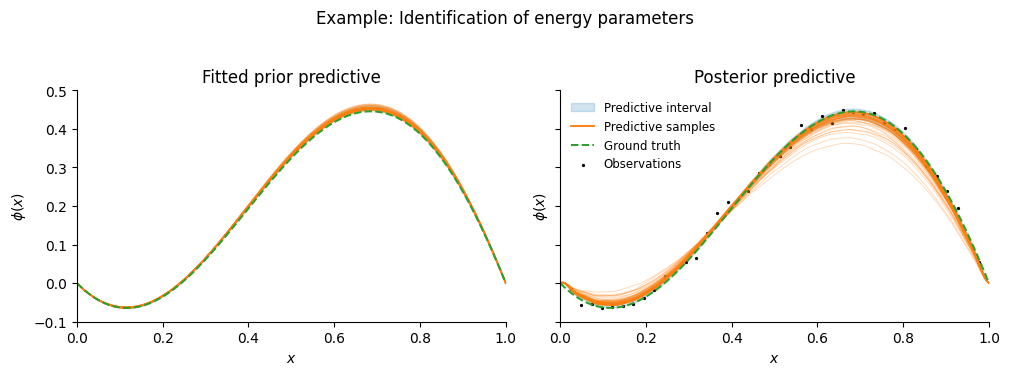

Saved PIFT_Example53a_predictive_two_panel.svg


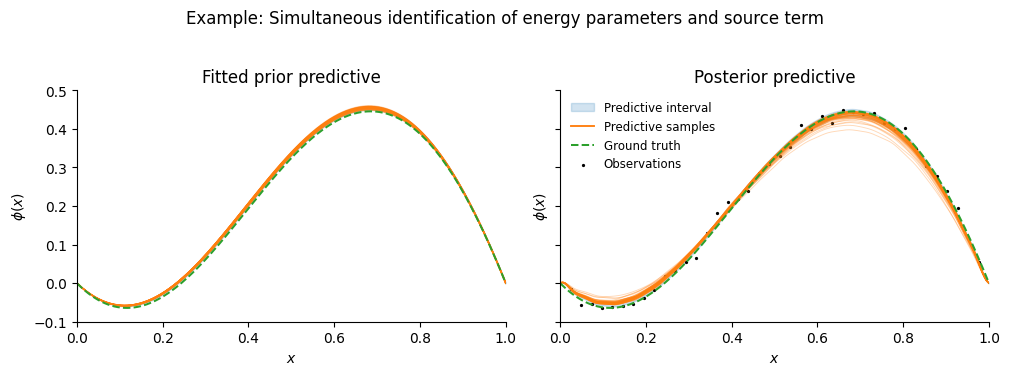

Saved PIFT_Example53b_predictive_two_panel.svg


In [39]:
import numpy as np
import matplotlib.pyplot as plt
def plot_two_panel_predictive(
    x_np,
    phi_true_np,
    x_obs_np,
    y_obs_np,
    prior_samples,
    prior_med,
    prior_lo,
    prior_hi,
    post_samples,
    post_mean,
    post_lo,
    post_hi,
    fig_title,
    left_title,
    right_title,
    svg_name,
    n_prior_lines=45,
    n_post_lines=45,
):
    fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharey=True)
    ax = axes[0]
    prior_samples = np.asarray(prior_samples)
    for i in range(min(n_prior_lines, prior_samples.shape[0])):
        ax.plot(x_np, prior_samples[i], lw=0.65, alpha=0.32, color="C1")
    ax.fill_between(x_np, prior_lo, prior_hi, alpha=0.20, color="C0", label="Predictive interval")
    ax.plot(x_np, prior_med, lw=1.35, color="C1", label="Predictive samples")
    ax.plot(x_np, phi_true_np, "--", lw=1.45, color="C2", label="Ground truth")
    ax.set_title(left_title)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$\phi(x)$")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.1, 0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax = axes[1]
    post_samples = np.asarray(post_samples)
    for i in range(min(n_post_lines, post_samples.shape[0])):
        ax.plot(x_np, post_samples[i], lw=0.65, alpha=0.30, color="C1")
    ax.fill_between(x_np, post_lo, post_hi, alpha=0.20, color="C0", label="Predictive interval")
    ax.plot(x_np, post_mean, lw=1.35, color="C1", label="Predictive samples")
    ax.plot(x_np, phi_true_np, "--", lw=1.45, color="C2", label="Ground truth")
    ax.scatter(x_obs_np, y_obs_np, s=7, color="k", marker=".", label="Observations")
    ax.set_title(right_title)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$\phi(x)$")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.1, 0.5)
    ax.legend(frameon=False, fontsize=8.5, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(fig_title, fontsize=12, y=1.03)
    fig.tight_layout()
    fig.savefig(svg_name, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved {svg_name}")
plot_two_panel_predictive(
    x_np=np.asarray(x_np),
    phi_true_np=np.asarray(phi_true_nl),
    x_obs_np=np.asarray(x_obs_nl),
    y_obs_np=np.asarray(y_obs_nl),
    prior_samples=np.asarray(fpp_fields),
    prior_med=np.asarray(fpp_med),
    prior_lo=np.asarray(fpp_lo),
    prior_hi=np.asarray(fpp_hi),
    post_samples=np.asarray(phi_post_53a_np),
    post_mean=np.asarray(phi_mean_53a),
    post_lo=np.asarray(phi_lo_53a),
    post_hi=np.asarray(phi_hi_53a),
    fig_title="Example: Identification of energy parameters",
    left_title="Fitted prior predictive",
    right_title="Posterior predictive",
    svg_name="PIFT_Example53a_predictive_two_panel.svg",
)
plot_two_panel_predictive(
    x_np=np.asarray(x_np),
    phi_true_np=np.asarray(phi_true_nl),
    x_obs_np=np.asarray(x_obs_nl),
    y_obs_np=np.asarray(y_obs_nl),
    prior_samples=np.asarray(fpp_b),
    prior_med=np.asarray(fpp_b_med),
    prior_lo=np.asarray(fpp_b_lo),
    prior_hi=np.asarray(fpp_b_hi),
    post_samples=np.asarray(phi_post_53b_np),
    post_mean=np.asarray(phi_mean_53b),
    post_lo=np.asarray(phi_lo_53b),
    post_hi=np.asarray(phi_hi_53b),
    fig_title="Example: Simultaneous identification of energy parameters and source term",
    left_title="Fitted prior predictive",
    right_title="Posterior predictive",
    svg_name="PIFT_Example53b_predictive_two_panel.svg",
)
